In [40]:
import os
from pycocotools.coco import COCO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [30]:
# 파일 경로 설정
data_root = r"C:\Dev\WheelScan\data"
train_img_dir = os.path.join(data_root, "train", "images")
train_label_dir = os.path.join(data_root, "train", "labels")

In [41]:
def create_dataframe(label_dir):
    annotations = []
    label_files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
    image_sizes = {}
    
    for label_file in label_files:
        image_name = os.path.splitext(label_file)[0] + '.jpg'
        image_id = os.path.splitext(label_file)[0]
        image_path = os.path.join(train_img_dir, image_name)
        try:
            with Image.open(image_path) as img:
                img_width, img_height = img.size
                image_sizes[image_name] = {'width': img_width, 'height': img_height}
        except Exception as e:
            print(f"Error reading {image_path}: {e}")
            image_sizes[image_name] = {'width': None, 'height': None}
        
        with open(os.path.join(label_dir, label_file), 'r') as f:
            lines = f.readlines()
        
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            
            class_id = int(parts[0])
            x_center = float(parts[1])
            y_center = float(parts[2])
            width = float(parts[3])
            height = float(parts[4])
            
            annotations.append({
                'image_id': image_id,
                'file_name': image_name,
                'category_id': class_id,
                'x_center': x_center,
                'y_center': y_center,
                'width': width,
                'height': height,
                'image_width': image_sizes[image_name]['width'],
                'image_height': image_sizes[image_name]['height']
            })
    
    df = pd.DataFrame(annotations)
    return df

In [42]:
df = create_dataframe(train_label_dir)
print(df.head())

                                            image_id  \
0  frame1501_jpg.rf.0a74c103b49ff55598ff38febd944c7c   
1  frame1501_jpg.rf.0a74c103b49ff55598ff38febd944c7c   
2  frame1501_jpg.rf.0a74c103b49ff55598ff38febd944c7c   
3  frame1501_jpg.rf.0a74c103b49ff55598ff38febd944c7c   
4  frame1501_jpg.rf.0a74c103b49ff55598ff38febd944c7c   

                                           file_name  category_id  x_center  \
0  frame1501_jpg.rf.0a74c103b49ff55598ff38febd944...            3  0.316293   
1  frame1501_jpg.rf.0a74c103b49ff55598ff38febd944...            0  0.621032   
2  frame1501_jpg.rf.0a74c103b49ff55598ff38febd944...            2  0.450397   
3  frame1501_jpg.rf.0a74c103b49ff55598ff38febd944...            1  0.536376   
4  frame1501_jpg.rf.0a74c103b49ff55598ff38febd944...            1  0.521825   

   y_center     width    height  image_width  image_height  
0  0.443931  0.298828  0.444033          640           640  
1  0.478543  0.677910  0.472264          640           640  
2  0.

In [43]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2485 entries, 0 to 2484
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   image_id      2485 non-null   object 
 1   file_name     2485 non-null   object 
 2   category_id   2485 non-null   int64  
 3   x_center      2485 non-null   float64
 4   y_center      2485 non-null   float64
 5   width         2485 non-null   float64
 6   height        2485 non-null   float64
 7   image_width   2485 non-null   int64  
 8   image_height  2485 non-null   int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 174.9+ KB
None


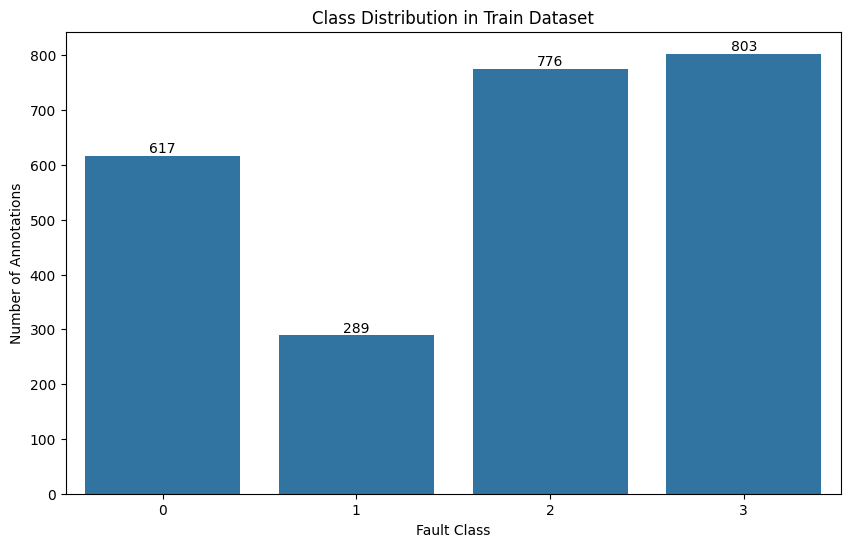

In [44]:
# 클래스 분포 시각화
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='category_id')
plt.title('Class Distribution in Train Dataset')
plt.xlabel('Fault Class')
plt.ylabel('Number of Annotations')
#plt.xticks(rotation=45)

# 각 막대 위에 갯수 표시
for i in ax.patches:
    ax.text(i.get_x() + i.get_width() / 2, i.get_height(),
            int(i.get_height()),
            ha='center', va='bottom')

plt.show()

class_counts = (
    df['category_id']
    .value_counts()
    .rename_axis('category_id')
    .reset_index(name='count')
)

In [ ]:
# 바운딩 박스가 이미지 내 차지하는 비율
df['bbox_width_abs'] = df['width'] * df['image_width']
df['bbox_height_abs'] = df['height'] * df['image_height']
# 바운딩 박스 면적 계산
df['area'] = df['bbox_width_abs'] * df['bbox_height_abs']
# 이미지 전체 면적 대비 비율 계산
df['area_ratio'] = df['area'] / (df['image_width'] * df['image_height'])

# 바운딩 박스 면적 비율 분포 시각화
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='area_ratio', bins=30, kde=True, color='#4ECDC4', alpha=0.7)
plt.title('Bounding Box Area Ratio Distribution in Train Dataset', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Area Ratio (relative to image size)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.axvline(df['area_ratio'].mean(), color='#FF6B6B', linestyle='--', label=f'Mean: {df["area_ratio"].mean():.3f}')
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

KeyError: 'area'